In [1]:
import ast
import glob
import warnings
from collections import defaultdict
from datetime import date

import numpy as np
import pandas as pd
import wandb

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import os
import json


today = date.today()
api = wandb.Api()

# # Find all csv files in the current directory
csv_files = glob.glob("csv/*.csv")
# # Collect all the names of the csv files without the extension
csv_names = [csv_file[:-4] for csv_file in csv_files]
project_name = "peekvit-ltrain"  
user = "telyatnikov_sap"

if project_name not in csv_names:
    runs = api.runs(f"{user}/{project_name}")

    summary_list, config_list, name_list = [], [], []
    for run in runs:
        # .summary contains the output keys/values for metrics like accuracy.
        #  We call ._json_dict to omit large files
        summary_list.append(run.summary._json_dict)

        # .config contains the hyperparameters.
        #  We remove special values that start with _.
        config_list.append(
            {k: v for k, v in run.config.items() if not k.startswith("_")}
        )

        # .name is the human-readable name of the run.
        name_list.append(run.name)

    runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

    runs_df.to_csv(f"csv/{user}_{project_name}.csv")
else:
    runs_df = pd.read_csv(f"csv/{user}_{project_name}.csv", index_col=0)

    for row in runs_df.iloc:
        row["summary"] = ast.literal_eval(row["summary"])
        row["config"] = ast.literal_eval(row["config"])


for row in runs_df.iloc:
    row["summary"].update(row["config"])

lst = [i["summary"] for i in runs_df.iloc]
df = pd.DataFrame.from_dict(lst)

df_init = df.copy()


In [2]:
def normalize_column(df, column_to_normalize):
    # Use json_normalize to flatten the nested dictionaries into separate columns
    flattened_df = pd.json_normalize(df[column_to_normalize])
    # Rename columns to include 'nested_column' prefix
    flattened_df.columns = [
        f"{column_to_normalize}.{col}" for col in flattened_df.columns
    ]
    # Concatenate the flattened DataFrame with the original DataFrame
    result_df = pd.concat([df, flattened_df], axis=1)
    # Get new columns names
    new_columns = flattened_df.columns
    # Drop the original nested column if needed
    result_df.drop(column_to_normalize, axis=1, inplace=True)
    return result_df, new_columns


# Config columns to normalize
columns_to_normalize = ["decoder", 'compressor']

# Keep track of config columns added
config_columns = []
for column in columns_to_normalize:
    df, columns = normalize_column(df, column)
    config_columns.extend(columns)



# substitute NaN with 'NA'
df.fillna('NA', inplace=True)
df['compressor.r'] = df['compressor.r'].apply(lambda x: str(x))
df['Elements compression'] = df['Elements compression'].apply(lambda x: np.round((1 - x)*100))
# Rename No Compression to VIT
rename_dict = {'No Compression': 'VIT', 'Tome':'TVIT', 'AE':'AEVIT', 'PCA':'PCAVIT', "Tome+AE":'TAEVIT'}
df['compressor.name'] = df['compressor.name'].apply(lambda x: rename_dict[x])

/tmp/ipykernel_1624571/2363981188.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('NA', inplace=True)


In [3]:
from collections import defaultdict

results = defaultdict(dict)
df['model_type'].dropna(inplace=True)
#df[['model_type',  'decoder.use_trace_loss', 'Token compression', 'val/best_accuracy', 'validate_snr_db']]
df['model_type'] = df['model_type'].apply(lambda x: ' '.join(x.split('_')[-2:]))

In [4]:
df = df.loc[df['reconstruct_images'] == True]

In [5]:
df['compressor.r'] 

0            [5, 5, 5, 5, 5, 5]
1            [2, 2, 2, 2, 2, 2]
2      [40, 40, 40, 40, 40, 40]
3      [30, 30, 30, 30, 30, 30]
4      [20, 20, 20, 20, 20, 20]
                 ...           
285    [30, 30, 30, 30, 30, 30]
286    [20, 20, 20, 20, 20, 20]
287    [10, 10, 10, 10, 10, 10]
288          [5, 5, 5, 5, 5, 5]
289          [2, 2, 2, 2, 2, 2]
Name: compressor.r, Length: 290, dtype: object

In [6]:

# df.experiments_dir df.experiment_name
# Go over the rows and create path
new_col = []
for i, row in df.iterrows():
    new_col.append(f"{row['experiments_dir']}{row['experiment_name']}")

df['path'] = new_col

In [7]:
df['path'].head(5)

0    log/runs/2024-09-04-17-34-49
1    log/runs/2024-09-04-16-56-56
2    log/runs/2024-09-04-16-17-15
3    log/runs/2024-09-04-15-37-42
4    log/runs/2024-09-04-14-56-01
Name: path, dtype: object

In [8]:
sorted(df['Elements compression'])[:10]

[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 15.0, 15.0, 15.0, 15.0]

In [17]:
df['val/best_accuracy'].dropna(inplace=True)

In [28]:
df = df[df['val/best_accuracy'] != 'NA']

In [30]:
# for each 'compressor.r value leave the rows with the best accuracy and choose from compressor.encoding_dim
df = df.loc[df.groupby(['compressor.r', 'compressor.encoding_dim'])['val/best_accuracy'].idxmax()]


In [33]:
df['Elements compression']

47    79.0
41    72.0
35    65.0
29    58.0
23    51.0
17    44.0
11    38.0
5     31.0
97    72.0
43    62.0
37    53.0
79    43.0
25    34.0
67    25.0
13    15.0
7      6.0
46    88.0
40    84.0
34    81.0
28    77.0
22    73.0
16    69.0
10    65.0
4     61.0
45    96.0
39    95.0
33    94.0
27    93.0
21    92.0
15    91.0
9     89.0
3     88.0
44    98.0
38    98.0
32    97.0
26    97.0
20    96.0
14    96.0
8     95.0
2     95.0
48    74.0
42    66.0
84    58.0
78    49.0
72    40.0
18    32.0
12    24.0
6     15.0
Name: Elements compression, dtype: float64

### Main comrapison

/tmp/ipykernel_1624571/3847621275.py:223: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=3)  # Increase space between subplots


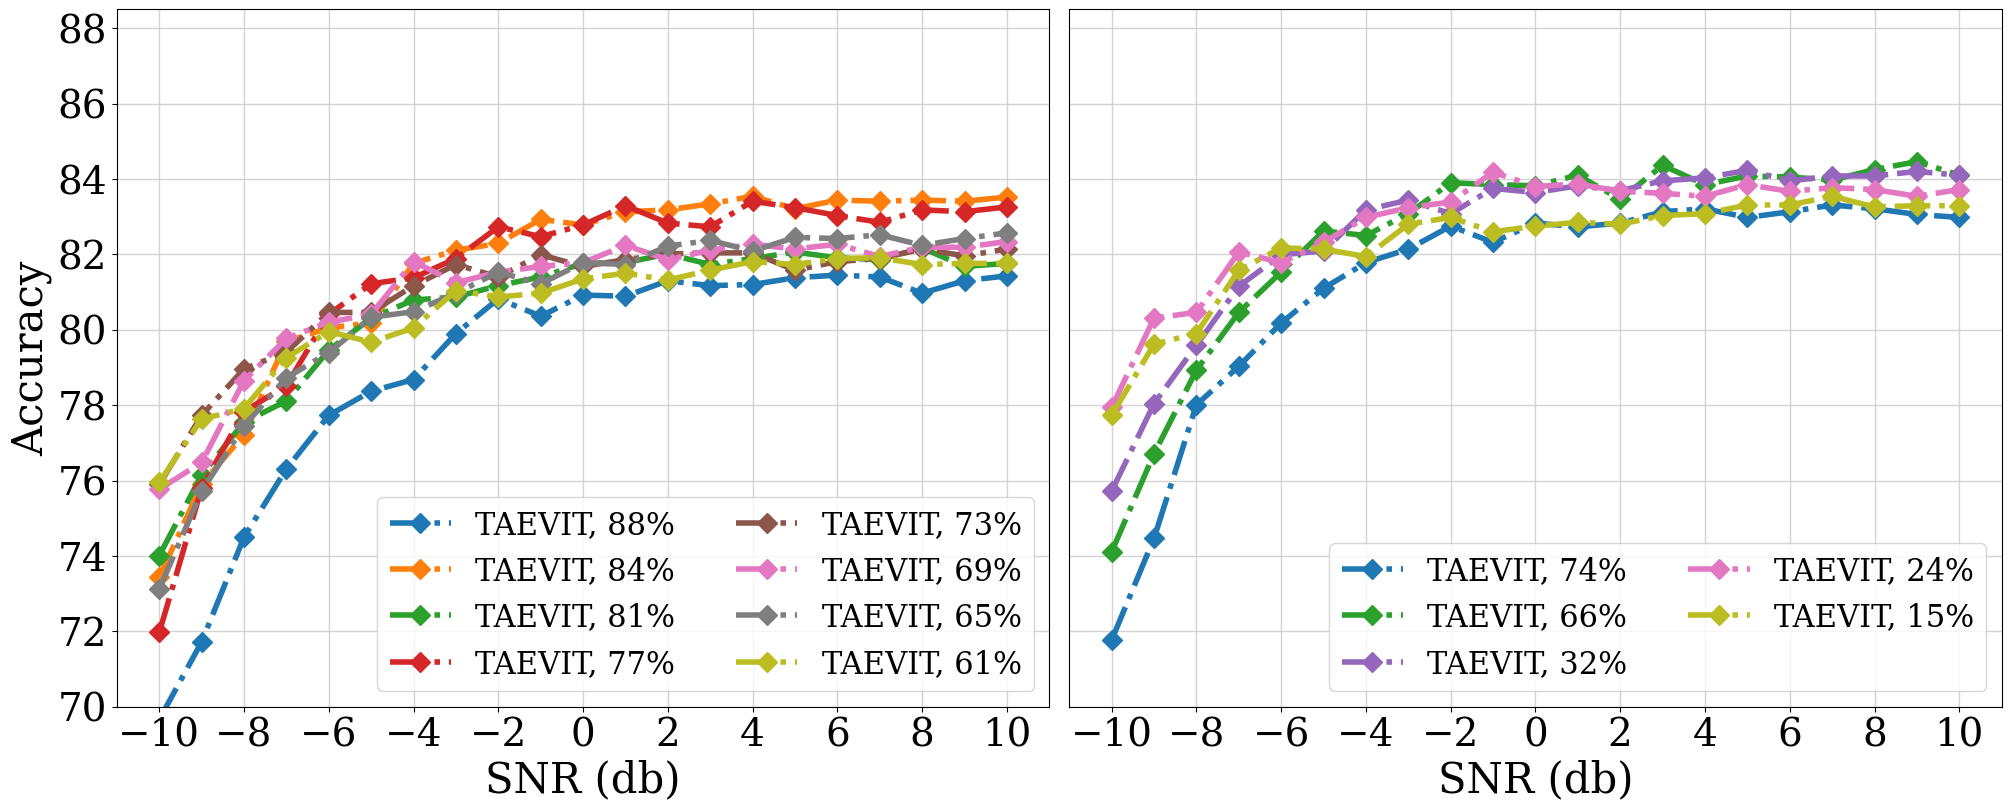

In [41]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Shared and personalized sweep columns
shared_sweep_columns = [
    'compressor.name', 
    'train_classifier_separetely', 
    'train_snr_db', 
    'Elements compression'
]

personalised_sweep_columns = {
    'AEVIT': ['compressor.encoding_dim'] + shared_sweep_columns,
    'TVIT': ['compressor.use_trace_loss', 'compressor.r'] + shared_sweep_columns,
    'PCAVIT': ['compressor.q'] + shared_sweep_columns,
    'VIT': shared_sweep_columns,
    'TAEVIT': ['compressor.encoding_dim', 'compressor.use_trace_loss', 'compressor.r'] + shared_sweep_columns,
}

# Filter conditions for each model
filter_conditions = {
    0: {
         'TAEVIT': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False],
            'compressor.use_trace_loss': [True],
            #'Elements compression': [15., 31., 88., 95.], 
            #'compressor.encoding_dim': [173],
            'compressor.r': ['[20, 20, 20, 20, 20, 20]'] # '[20, 20, 20, 20, 20, 20]', '[5, 5, 5, 5, 5, 5]'
            
            
        },
        # 'TVIT': {
        #     'train_snr_db': [0], 
        #     'train_classifier_separetely': [False], 
        #     #'Elements compression': [15., 31., 88., 95.], 
        #     'compressor.use_trace_loss': [True],
        #     'compressor.r': [[40, 40, 40, 40, 40, 40], [20, 20, 20, 20, 20, 20], [5, 5, 5, 5, 5, 5]]
        # },
       
        # 'VIT': {
        #     'train_snr_db': [0], 
        #     'train_classifier_separetely': [False], 
        #     'Elements compression': [0]
        # }
        },
    1: {
        'TAEVIT': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False],
            'compressor.use_trace_loss': [True],
            #'Elements compression': [84., 66.,], 
            #'compressor.encoding_dim': [173],
            'compressor.r': ['[5, 5, 5, 5, 5, 5]']
        },
        # 'TVIT': {
        #     'train_snr_db': ['random'], 
        #     'train_classifier_separetely': [False], 
        #     'Elements compression': [15., 31., 88., 95.], 
        #     'compressor.use_trace_loss': [True]
        # },
        # 'VIT': {
        #     'train_snr_db': ['random'], 
        #     'train_classifier_separetely': [False], 
        #     'Elements compression': [0]
        # }
        },
    2: {
        # 'AEVIT': {
        #     'train_snr_db': [0], 
        #     'train_classifier_separetely': [False], 
        #     'Elements compression': [70, 40, 10]
        # },
        'TVIT': {
            'train_snr_db': ['random', 0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [ 15,  88.],  # 88., 95.
            'compressor.use_trace_loss': [True, False]
        },
        
        'VIT': {
            'train_snr_db': [0], 
            'train_classifier_separetely': [False], 
            'Elements compression': [0]
        }},
}


# Line styles and markers for each model
line_styles = {
    "AEVIT": 'dotted', 
    "TVIT": 'solid', 
    "PCAVIT": 'dashdot', 
    "VIT": '--',
    "TAEVIT": 'dashdot', 
}
markers = {
    "AEVIT": 'o', 
    "TVIT": 's', 
    "PCAVIT": 'D', 
    "VIT": 'x',
    "TAEVIT": 'D', 
}

# Plotting settings
settings = {
    'font.family': 'serif',
    'text.latex.preamble': '\\renewcommand{\\rmdefault}{ptm}\\renewcommand{\\sfdefault}{phv}',
    'figure.figsize': (20, 8),  # Adjusted figure size for two columns
    'figure.constrained_layout.use': True,
    'figure.autolayout': False,
    'font.size': 16,
    'axes.labelsize': 30,
    'legend.fontsize': 22,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'axes.titlesize': 50
}
df_copy = df.copy()
with plt.rc_context(settings):
    num_plots = 2
    fig, axs = plt.subplots(1, num_plots, figsize=(20, 8))  # Create 3 subplots in a 1x3 grid
    for ax_idx in range(num_plots):
        ax = axs[ax_idx]

        unique_combinations_collector = pd.DataFrame()
        ax_fc = filter_conditions[ax_idx]
        for compressor_name in ax_fc.keys():
            compressor_df = df.loc[df['compressor.name'] == compressor_name]
            sweep_columns = personalised_sweep_columns[compressor_name]
            unique_combinations = compressor_df[sweep_columns].drop_duplicates()

            # Filter according to conditions
            for condition, values in ax_fc[compressor_name].items():
                unique_combinations = unique_combinations.loc[unique_combinations[condition].isin(values)]

            unique_combinations_collector = pd.concat([unique_combinations_collector, unique_combinations])

        if ax_idx == 2:
            # Change the model name if use_trace_loss == True and compressor.name is TVIT then TVIT_trace, else keep the same name  
            # Define a function to update the model name based on conditions
            def update_name(row):
                
                if row['compressor.use_trace_loss'] and row['compressor.name'] == 'TVIT':
                    return 'TVIT_trace'
                return row['compressor.name']

            # Apply the function to the DataFrame
            unique_combinations_collector['compressor.name'] = unique_combinations_collector.apply(update_name, axis=1)
            df_copy['compressor.name'] = df_copy.apply(update_name, axis=1)

        # Assign unique colors for each combination
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_combinations_collector) + 1))
        color_dict = {idx: colors[i] for i, idx in enumerate(unique_combinations_collector.index)}

        unique_combinations_collector.fillna('NA', inplace=True)

        
        for idx, combination in unique_combinations_collector.iterrows():
            selected_idx = [df_copy[key] == val for key, val in combination.items()]
            mask = np.logical_and.reduce(selected_idx)
            subset = df_copy[mask]
            path_to_json = os.path.join(subset['path'].item(), 'results.json')

            # Load and plot results
            with open(path_to_json, 'r') as f:
                results = json.load(f)

            snr = np.array(list(results.keys())).astype(float)
            accuracy = np.array([results[key]['test/accuracy'] * 100 for key in results.keys()]).round(2)
            
            ax.plot(
                snr.astype(int),
                accuracy,
                marker=markers[combination['compressor.name']],
                color=color_dict[idx],
                linestyle=line_styles[combination['compressor.name']],
                lw=4,
                markersize=10,
            )

            # Create legend elements
            legend_elements = [
                Line2D(
                    [0], [0], 
                    color=color_dict[idx], 
                    lw=4, 
                    linestyle=line_styles[combination['compressor.name']], 
                    marker=markers[combination['compressor.name']],
                    markersize=10, 
                    label=f"{combination['compressor.name']}, {int(combination['Elements compression'])}%"
                ) 
                for idx, combination in unique_combinations_collector.iterrows()
            ]

            # Add legends to the first subplot
            ax.legend(handles=legend_elements, ncol=2, loc='lower right')
        
       

    # Set x-ticks to integer values and adjust labels for both subplots
    for idx, ax in enumerate(axs):
        ax.set_ylim(70, 88.5)
        ax.set_xticks(snr.astype(int)[::2])
        ax.set_xlabel('SNR (db)', fontsize=30)
        ax.grid(True,  color='lightgray', linestyle='-', linewidth=1, zorder=0)

        if idx == 0:
            ax.set_ylabel('Accuracy', fontsize=30)
            ax.set_yticks(np.arange(70, 90, 2))
        else:
            ax.set_yticks([])  # Remove y-ticks from the second and third subplots
            ax.grid(True, axis='y', linestyle='--')  # Force y-axis grid with custom linestyle

            # Add y-axis grid lines manually
            for ytick in np.arange(70, 90, 2):
                ax.axhline(y=ytick, color='lightgray', linestyle='-', linewidth=1, zorder=0)
    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=3)  # Increase space between subplots

# Save and show plot
output_pdf_path = f"images/performance_plot_{today}.pdf"
plt.savefig(output_pdf_path, bbox_inches='tight')
plt.show()


In [40]:
unique_combinations_collector

,compressor.encoding_dim,compressor.use_trace_loss,compressor.r,compressor.name,train_classifier_separetely,train_snr_db,Elements compression
48,58,True,"[5, 5, 5, 5, 5, 5]",TAEVIT,False,0,74.0
42,77,True,"[5, 5, 5, 5, 5, 5]",TAEVIT,False,0,66.0
18,154,True,"[5, 5, 5, 5, 5, 5]",TAEVIT,False,0,32.0
12,173,True,"[5, 5, 5, 5, 5, 5]",TAEVIT,False,0,24.0
6,192,True,"[5, 5, 5, 5, 5, 5]",TAEVIT,False,0,15.0


In [99]:
df['compressor.r'].unique()

array(['[5, 5, 5, 5, 5, 5]', '[2, 2, 2, 2, 2, 2]',
       '[40, 40, 40, 40, 40, 40]', '[30, 30, 30, 30, 30, 30]',
       '[20, 20, 20, 20, 20, 20]', '[10, 10, 10, 10, 10, 10]'],
      dtype=object)

{'TAEVIT': {'train_snr_db': [0], 'train_classifier_separetely': [False]},
 1: {'TAEVIT': {'train_snr_db': ['random'],
   'train_classifier_separetely': [False]}}}